# Notebook Description

Regresses the 8-sleeve stat-arb portfolio's net daily returns on SPY for each calendar year (2015–2026), plus aggregate in-sample, out-of-sample, and full-history periods.

Notes:
- Portfolio: equal-vol weighted, 10% vol target, 10 bps transaction costs
- In-sample period: 2015–2023
- Out-of-sample period: 2024–2026

## Setup

In [19]:
from __future__ import annotations

import warnings
from functools import cache

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import qstudy as qs
from qstudy.constants import SP500

In [20]:
START_DATE = '2015-01-01'
IS_END     = '2023-12-31'
OOS_END    = '2026-04-30'
OOS_SPLIT  = pd.Timestamp('2024-01-01')
COST_BPS   = 10.0
N_LONG = N_SHORT = 20
FACTORS = ['SPY', 'XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLRE', 'XLB']

GICS_TO_ETF = {
    'Technology': 'XLK', 'Financial Services': 'XLF', 'Energy': 'XLE',
    'Healthcare': 'XLV', 'Industrials': 'XLI', 'Consumer Cyclical': 'XLY',
    'Consumer Defensive': 'XLP', 'Utilities': 'XLU', 'Real Estate': 'XLRE',
    'Basic Materials': 'XLB', 'Communication Services': 'XLK',
}

PORTFOLIO_ORDER = [
    'factor_model_resid_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75',
    'mr_5d__r10__trend_50_200__cond__breadth_weak_40',
    'dist_mr_k3_z20__r21__cond__vol_contraction_10_60',
    'dist_mr_k3_z60__r5__cond__vol_expansion_10_60',
    'dist_mr_k3_z60__r10__cond__none',
    'dist_mr_k3_z10__r10__cond__panic_10d_minus5',
    'monoton_120d__r21__crash_10_5pct',
    'resid_gap_reversion__r10__breadth_40',
]

PORTFOLIO_SHORT = {
    'factor_model_resid_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75': 'Residual MR',
    'mr_5d__r10__trend_50_200__cond__breadth_weak_40':                                    'Active-Return MR',
    'dist_mr_k3_z20__r21__cond__vol_contraction_10_60':                                   'DPMR z20',
    'dist_mr_k3_z60__r5__cond__vol_expansion_10_60':                                      'DPMR z60 expansion',
    'dist_mr_k3_z60__r10__cond__none':                                                     'DPMR z60 always-on',
    'dist_mr_k3_z10__r10__cond__panic_10d_minus5':                                         'DPMR z10 panic',
    'monoton_120d__r21__crash_10_5pct':                                                    'Monotonic Momentum',
    'resid_gap_reversion__r10__breadth_40':                                                'Resid. Gap Reversion',
}

print(f'SP500 universe: {len(SP500)} tickers')

SP500 universe: 499 tickers


## Data Loaders

In [21]:
@cache
def load_universe():
    return qs.download(SP500, START_DATE, IS_END)

@cache
def load_benchmark():
    return qs.download(['SPY'], START_DATE, IS_END)

@cache
def load_factors():
    return qs.download(FACTORS, START_DATE, IS_END)

@cache
def load_oos_universe():
    return qs.download(SP500, START_DATE, OOS_END)

@cache
def load_oos_benchmark():
    return qs.download(['SPY'], START_DATE, OOS_END)

@cache
def load_oos_factors():
    return qs.download(FACTORS, START_DATE, OOS_END)

@cache
def load_sector_map():
    return qs.get_sector_map(SP500)

@cache
def load_distance_partners():
    universe  = load_universe()
    log_price = universe.log_returns.cumsum()
    norm      = (log_price - log_price.mean()) / log_price.std().clip(lower=1e-8)
    dist      = 1 - norm.corr()
    partners  = {}
    for zw in [10, 20, 60]:
        p = {}
        for ticker in dist.columns:
            p[ticker] = dist[ticker].drop(ticker).nsmallest(3).index.tolist()
        partners[zw] = p
    return partners

u = load_universe()
print(f'  Universe : {u.returns.shape[0]} days x {u.returns.shape[1]} tickers')
print(f'  Benchmark: {load_benchmark().returns.shape}')

Task was destroyed but it is pending!
task: <Task pending name='Task-173' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/jplatta/repos/portfolio-research/.venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-174' coro=<Kernel.shell_main() running at /Users/jplatta/repos/portfolio-research/.venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/jplatta/repos/portfolio-research/.venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/jplatta/repos/portfolio-research/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3669: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  to_run = []
Task was destroyed but it is pending!
task: <Task pending name='Task-174' coro=<Kernel.shell_main() running at /Users/jplatta/repos/portfolio-research/.venv/lib/python3.11/site-packages/ipykernel/kernelb

  Universe : 2264 days x 461 tickers
  Benchmark: (2264, 1)


## Signal, Filter & Scaler Functions

In [25]:
def make_mr_5d():
    def mr_5d(**cache):
        return -cache['_active_returns'].rolling(5).mean()
    
    mr_5d.__name__ = 'mr_5d'
    
    return mr_5d

def make_factor_model_resid_mr_5d():
    def factor_model_resid_mr_5d(**cache):
        return -cache['residual_returns'].rolling(5).mean()
    
    factor_model_resid_mr_5d.__name__ = 'factor_model_resid_mr_5d'
    
    return factor_model_resid_mr_5d

def make_dist_mr(zw: int):
    def dist_mr(**cache):
        r = cache['_active_returns']
        partners = load_distance_partners()[zw]
        price = (1 + r).cumprod()
        norm = price / price.iloc[0].clip(lower=1e-8)
        spread = pd.DataFrame(index=r.index, columns=r.columns, dtype=float)
        for ticker in r.columns:
            peers = [p for p in partners.get(ticker, []) if p in r.columns]
            if peers:
                spread[ticker] = norm[ticker] - norm[peers].mean(axis=1)
        mu = spread.rolling(zw).mean()
        sigma = spread.rolling(zw).std().clip(lower=1e-8)
        
        return -((spread - mu) / sigma).clip(-2, 2)
    
    dist_mr.__name__ = f'dist_mr_k3_z{zw}'
    
    return dist_mr

def make_dist_mr_oos(zw: int):
    # NOTE: IS-period partners
    partners = load_distance_partners()[zw]  
    
    def dist_mr(**cache):
        r = cache['_active_returns']
        price = (1 + r).cumprod()
        norm_p = price / price.iloc[0].clip(lower=1e-8)
        spread = pd.DataFrame(index=r.index, columns=r.columns, dtype=float)
        for ticker in r.columns:
            peers = [p for p in partners.get(ticker, []) if p in r.columns]
            if peers:
                spread[ticker] = norm_p[ticker] - norm_p[peers].mean(axis=1)
        mu = spread.rolling(zw).mean()
        sigma = spread.rolling(zw).std().clip(lower=1e-8)
        
        return -((spread - mu) / sigma).clip(-2, 2)
    
    dist_mr.__name__ = f'dist_mr_k3_z{zw}'
    
    return dist_mr

def make_monoton_120d():
    def monoton_120d(**cache):
        r = cache['_active_returns']
        mu = r.rolling(120).mean()
        same_sign = (r.gt(0) == mu.gt(0)).astype(float)
        
        return same_sign.rolling(120).mean() * mu.abs()
    
    monoton_120d.__name__ = 'monoton_120d'
    
    return monoton_120d

def make_resid_gap_reversion():
    def resid_gap_reversion(**cache):
        return -cache['residual_returns'].shift(1)
        
    resid_gap_reversion.__name__ = 'resid_gap_reversion'
    
    return resid_gap_reversion

def filter_residual_dispersion_high_20_q75(signal, **cache):
    resid = cache['residual_returns']
    disp = resid.std(axis=1).rolling(20).mean()
    thresh = disp.rolling(252).quantile(0.75)
    mask = disp.gt(thresh).reindex(signal.index).fillna(False)
    
    return signal.where(mask, other=np.nan)

filter_residual_dispersion_high_20_q75.__name__ = 'residual_dispersion_high_20_q75'

def filter_breadth_weak_40(signal, **cache):
    prices = (1 + cache['returns']).cumprod()
    pct_abv = (prices > prices.rolling(200).mean()).mean(axis=1)
    mask = pct_abv.lt(0.40).reindex(signal.index).fillna(False)
    
    return signal.where(mask, other=np.nan)

filter_breadth_weak_40.__name__ = 'breadth_weak_40'

def filter_vol_contraction_10_60(signal, **cache):
    bm = cache['benchmark']
    mask = bm.rolling(10).std().lt(bm.rolling(60).std()).reindex(signal.index).fillna(False)
    
    return signal.where(mask, other=np.nan)

filter_vol_contraction_10_60.__name__ = 'vol_contraction_10_60'

def filter_vol_expansion_10_60(signal, **cache):
    bm = cache['benchmark']
    mask = bm.rolling(10).std().gt(bm.rolling(60).std()).reindex(signal.index).fillna(False)
    
    return signal.where(mask, other=np.nan)

filter_vol_expansion_10_60.__name__ = 'vol_expansion_10_60'

def filter_panic_10d_minus5(signal, **cache):
    bm = cache['benchmark']
    mask = bm.rolling(10).sum().lt(-0.05).reindex(signal.index).fillna(False)
    
    return signal.where(mask, other=np.nan)

filter_panic_10d_minus5.__name__ = 'panic_10d_minus5'

def equity_curve_regime_scale(positions, **cache):
    returns = cache['returns']
    _tm = cache.get('_tradeable_mask')
    _lm = cache.get('_liquidity_mask')
    
    mask = _tm if _tm is not None else _lm
    
    r = returns.where(mask) if mask is not None else returns
    raw = (positions.shift(1) * r).sum(axis=1)
    equity = (1 + raw).cumprod()
    scale = pd.Series(np.where(equity > equity.rolling(20).mean(), 1.0, 0.25), index=equity.index)
    
    return positions.mul(scale.shift(1), axis=0)

equity_curve_regime_scale.__name__ = 'equity_curve_regime_scale'

def make_trend_scaler(fast: int, slow: int, mr_style: bool = True, scale_down: float = 0.25):
    def _trend(positions, **cache):
        bm = cache['benchmark']
        spy = (1 + bm).cumprod()
        up = spy.rolling(fast).mean().gt(spy.rolling(slow).mean()).reindex(positions.index).fillna(False)
        cond = up if mr_style else ~up
        scale = pd.Series(np.where(cond, scale_down, 1.0), index=positions.index)
        
        return positions.mul(scale.shift(1), axis=0)
    
    _trend.__name__ = f'trend_{fast}_{slow}'
    
    return _trend

def make_crash_scaler(window: int = 10, threshold: float = 0.05):
    def _crash(positions, **cache):
        bm = cache['benchmark']
        rebound = bm.rolling(window).sum().gt(threshold).reindex(positions.index).fillna(False)
        scale = pd.Series(np.where(rebound, 0.25, 1.0), index=positions.index)
        
        return positions.mul(scale.shift(1), axis=0)
    
    _crash.__name__ = f'crash_{window}_{int(threshold*100)}pct'
    
    return _crash

def make_breadth_scaler(threshold: float):
    def _breadth(positions, **cache):
        prices = (1 + cache['returns']).cumprod()
        pct_abv = (prices > prices.rolling(200).mean()).mean(axis=1)
        weak = pct_abv.lt(threshold).reindex(positions.index).fillna(False)
        scale = pd.Series(np.where(weak, 0.25, 1.0), index=positions.index)
        
        return positions.mul(scale.shift(1), axis=0)
    
    _breadth.__name__ = f'breadth_{int(threshold*100)}'
    
    return _breadth

print('Signal, filter, and scaler functions defined.')

Signal, filter, and scaler functions defined.


## Sleeve Runner & Portfolio Definitions

In [26]:
def run_sleeve(
    signal_fn, 
    conditioning_filter, 
    rebalance_every, 
    risk_scalers,
    use_factor_model, 
    use_etf_resid, 
    needs_resid_cache,
    universe=None, 
    benchmark=None, 
    factors=None
) -> Study:
    if universe is None:  universe  = load_universe()
    if benchmark is None: benchmark = load_benchmark()
    if factors is None:   factors   = load_factors()
        
    builder = qs.Study(universe=universe, benchmark=benchmark, factors=factors, verbose=False)
    
    if use_factor_model:
        builder = builder.add_factor_model(factors=['market', 'sector'], sector_map=load_sector_map())
        
    if use_factor_model or use_etf_resid or needs_resid_cache:
        builder = builder.residualize_returns()
        
    builder = builder.base_signal(signal_fn)
    if conditioning_filter is not None:
        builder = builder.add_filter(conditioning_filter)
        
    builder = (
        builder
        .add_tradeable_constraint(qs.liquidity(top_n=300))
        .rank_transform()
        .build_long_short(n_long=N_LONG, n_short=N_SHORT)
        .fully_invest()
        .scale_risk(fn=equity_curve_regime_scale)
    )
    
    for scaler_fn in risk_scalers:
        builder = builder.scale_risk(fn=scaler_fn)
        
    return builder.rebalance(every=rebalance_every).run()


def build_portfolio(sleeve_studies, universe, benchmark) -> PortfolioStudy:
    port = qs.PortfolioStudy(
        strategies=[sleeve_studies[l] for l in PORTFOLIO_ORDER],
        universe=universe, benchmark=benchmark,
        name='8-Sleeve Stat Arb', cost_bps=COST_BPS, verbose=False,
    )
    return port.weight_equal_vol().leverage(vol_target=0.10).with_transaction_costs(COST_BPS).run()

PORTFOLIO_DEFS = {
    'factor_model_resid_mr_5d__r10__trend_20_100__cond__residual_dispersion_high_20_q75': (
        make_factor_model_resid_mr_5d(), filter_residual_dispersion_high_20_q75, 10,
        [make_trend_scaler(20, 100, mr_style=True)], True, False, False,
    ),
    'mr_5d__r10__trend_50_200__cond__breadth_weak_40': (
        make_mr_5d(), filter_breadth_weak_40, 10,
        [make_trend_scaler(50, 200, mr_style=True)], False, False, False,
    ),
    'dist_mr_k3_z20__r21__cond__vol_contraction_10_60': (
        make_dist_mr(20), filter_vol_contraction_10_60, 21, [], False, False, False,
    ),
    'dist_mr_k3_z60__r5__cond__vol_expansion_10_60': (
        make_dist_mr(60), filter_vol_expansion_10_60, 5, [], False, False, False,
    ),
    'dist_mr_k3_z60__r10__cond__none': (
        make_dist_mr(60), None, 10, [], False, False, False,
    ),
    'dist_mr_k3_z10__r10__cond__panic_10d_minus5': (
        make_dist_mr(10), filter_panic_10d_minus5, 10, [], False, False, False,
    ),
    'monoton_120d__r21__crash_10_5pct': (
        make_monoton_120d(), None, 21, [make_crash_scaler(10, 0.05)], False, False, False,
    ),
    'resid_gap_reversion__r10__breadth_40': (
        make_resid_gap_reversion(), None, 10, [make_breadth_scaler(0.40)], False, True, False,
    ),
}

print(f'Portfolio sleeves: {len(PORTFOLIO_DEFS)}')

Portfolio sleeves: 8


## Build IS Portfolio (2015–2023)

In [27]:
print(f'Running {len(PORTFOLIO_ORDER)} IS sleeves ({START_DATE} to {IS_END})')

is_sleeve_studies = {}
for label in PORTFOLIO_ORDER:
    sig_fn, cond_filter, rebal, scalers, use_fm, use_etf, needs_resid = PORTFOLIO_DEFS[label]
    print(f'\n{PORTFOLIO_SHORT[label]}:')
    
    is_sleeve_studies[label] = run_sleeve(
        signal_fn=sig_fn, 
        conditioning_filter=cond_filter,
        rebalance_every=rebal, 
        risk_scalers=scalers,
        use_factor_model=use_fm, 
        use_etf_resid=use_etf, 
        needs_resid_cache=needs_resid
    )
    
    metrics = is_sleeve_studies[label].metrics_dict()
    print(f"sharpe={metrics.get('sharpe'):.3f}")

is_port = build_portfolio(is_sleeve_studies, load_universe(), load_benchmark())
is_net_ret = is_port.cache['portfolio_returns'].dropna()
is_bm_ret = load_benchmark().returns['SPY']
m = is_port.metrics_dict()

print(f"\nIn-sample Net Sharpe: {m.get('net_sharpe'):.3f} | {len(is_net_ret)} observations")

Running 8 IS sleeves (2015-01-01 to 2023-12-31)

Residual MR:
Using barra-lite factor model for residuals...
sharpe=1.189

Active-Return MR:
sharpe=1.097

DPMR z20:
sharpe=1.291

DPMR z60 expansion:
sharpe=1.392

DPMR z60 always-on:
sharpe=1.550

DPMR z10 panic:
sharpe=1.004

Monotonic Momentum:
sharpe=0.878

Resid. Gap Reversion:
Using factors for residuals...
sharpe=1.202

In-sample Net Sharpe: 2.115 | 2264 observations


## Build Full-History Portfolio (2015–2026)

In [28]:
oos_univ = load_oos_universe()
oos_bm   = load_oos_benchmark()
oos_fac  = load_oos_factors()

OOS_DEFS = dict(PORTFOLIO_DEFS)
OOS_DEFS['dist_mr_k3_z20__r21__cond__vol_contraction_10_60'] = (
    make_dist_mr_oos(20), filter_vol_contraction_10_60, 21, [], False, False, False
)
OOS_DEFS['dist_mr_k3_z60__r5__cond__vol_expansion_10_60'] = (
    make_dist_mr_oos(60), filter_vol_expansion_10_60, 5, [], False, False, False
)
OOS_DEFS['dist_mr_k3_z60__r10__cond__none'] = (
    make_dist_mr_oos(60), None, 10, [], False, False, False
)
OOS_DEFS['dist_mr_k3_z10__r10__cond__panic_10d_minus5'] = (
    make_dist_mr_oos(10), filter_panic_10d_minus5, 10, [], False, False, False
)

print(f'Running {len(PORTFOLIO_ORDER)} sleeves on full data ({START_DATE} to {OOS_END})')
oos_sleeve_studies = {}

for label in PORTFOLIO_ORDER:
    sig_fn, cond_filter, rebal, scalers, use_fm, use_etf, needs_resid = OOS_DEFS[label]
    print(f'{PORTFOLIO_SHORT[label]}:')
    
    oos_sleeve_studies[label] = run_sleeve(
        signal_fn=sig_fn, 
        conditioning_filter=cond_filter,
        rebalance_every=rebal, 
        risk_scalers=scalers,
        use_factor_model=use_fm, 
        use_etf_resid=use_etf, 
        needs_resid_cache=needs_resid,
        universe=oos_univ, 
        benchmark=oos_bm, 
        factors=oos_fac
    )
    m = oos_sleeve_studies[label].metrics_dict()
    print(f"sharpe={m.get('sharpe'):.3f}")

full_port = build_portfolio(oos_sleeve_studies, oos_univ, oos_bm)
full_net_ret = full_port.cache['portfolio_returns'].dropna()
full_bm_ret = oos_bm.returns['SPY']
m = full_port.metrics_dict()

print(f"\nFull-history Net Sharpe: {m.get('net_sharpe'):.3f} | {len(full_net_ret)} observations")

Running 8 sleeves on full data (2015-01-01 to 2026-04-30)
Residual MR:
Using barra-lite factor model for residuals...
sharpe=0.879
Active-Return MR:
sharpe=1.061
DPMR z20:
sharpe=1.103
DPMR z60 expansion:
sharpe=1.065
DPMR z60 always-on:
sharpe=1.140
DPMR z10 panic:
sharpe=1.006
Monotonic Momentum:
sharpe=0.982
Resid. Gap Reversion:
Using factors for residuals...
sharpe=0.751

Full-history Net Sharpe: 1.583 | 2847 observations


## Run Annual Regressions

In [29]:
def run_regression(net_returns, bm_returns):
    idx = net_returns.index.intersection(bm_returns.index)
    y   = net_returns.loc[idx]
    x   = bm_returns.loc[idx]
    X   = sm.add_constant(x)
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})
    return model, y, x

def reg_stats(model, y, x):
    alpha_daily = model.params['const']
    ci = model.conf_int(alpha=0.05)
    return {
        'alpha_daily': alpha_daily,
        'alpha_annual': alpha_daily * 252,
        'alpha_ci_lo': float(ci.loc['const', 0]) * 252,
        'alpha_ci_hi': float(ci.loc['const', 1]) * 252,
        'beta': model.params['SPY'],
        't_alpha': model.tvalues['const'],
        't_beta': model.tvalues['SPY'],
        'p_alpha': model.pvalues['const'],
        'p_beta': model.pvalues['SPY'],
        'r_squared': model.rsquared,
        'n_obs': int(model.nobs),
        'skew': float(y.skew()),
        'kurtosis': float(y.kurt()),
        'ann_return': float((1 + y).prod() ** (252 / len(y)) - 1),
        'ann_vol': float(y.std() * np.sqrt(252)),
        'bm_ann_ret': float((1 + x).prod() ** (252 / len(x)) - 1),
    }

rows = []
for year in sorted(full_net_ret.index.year.unique()):
    y_ret = is_net_ret if year <= pd.Timestamp(IS_END).year else full_net_ret
    b_ret = is_bm_ret  if year <= pd.Timestamp(IS_END).year else full_bm_ret
    yr_y  = y_ret[y_ret.index.year == year]
    yr_x  = b_ret.reindex(yr_y.index).dropna()
    yr_y  = yr_y.reindex(yr_x.index)
    if len(yr_y) < 20:
        continue
    model, y, x = run_regression(yr_y, yr_x)
    s = reg_stats(model, y, x)
    s['period'] = str(year)
    s['label']  = 'OOS' if year >= OOS_SPLIT.year else 'IS'
    rows.append(s)

def agg(net_ret, bm_ret, period, label):
    model, y, x = run_regression(net_ret, bm_ret)
    s = reg_stats(model, y, x)
    s['period'] = period
    s['label']  = label
    return s

is_idx = is_net_ret.index.intersection(is_bm_ret.index)
rows.append(agg(is_net_ret.loc[is_idx], is_bm_ret.loc[is_idx], '2015–2023', 'IS'))

oos_y = full_net_ret[full_net_ret.index >= OOS_SPLIT]
oos_x = full_bm_ret[full_bm_ret.index >= OOS_SPLIT]
rows.append(agg(oos_y, oos_x, '2024–2026', 'OOS'))
rows.append(agg(full_net_ret, full_bm_ret, '2015–2026', 'ALL'))

print('Regressions complete.')

Regressions complete.


## Results Table

In [31]:
table_rows = []
for s in rows:
    sharpe = s['ann_return'] / s['ann_vol'] if s['ann_vol'] > 0 else float('nan')
    table_rows.append({
        'Period': s['period'],
        'Label': s['label'],
        'Ann Ret': f"{s['ann_return']:.1%}",
        'Ann Vol': f"{s['ann_vol']:.1%}",
        'Sharpe': round(sharpe, 3),
        'SPY Ret': f"{s['bm_ann_ret']:.1%}",
        'Alpha (ann)': f"{s['alpha_annual']:.1%}",
        'CI lo': f"{s['alpha_ci_lo']:.1%}",
        'CI hi': f"{s['alpha_ci_hi']:.1%}",
        't(alpha)': round(s['t_alpha'], 2),
        'p(alpha)': round(s['p_alpha'], 4),
        'Beta': round(s['beta'], 4),
        't(beta)': round(s['t_beta'], 2),
        'p(beta)': round(s['p_beta'], 4),
        'R2': round(s['r_squared'], 4),
        'Skew': round(s['skew'], 2),
        'Kurt': round(s['kurtosis'], 1),
        'N': s['n_obs'],
    })

df = pd.DataFrame(table_rows).set_index('Period')
df.to_csv('us-equity-stat-arb-alpha.csv', header=True)
df

,Label,Ann Ret,Ann Vol,Sharpe,SPY Ret,Alpha (ann),CI lo,CI hi,t(alpha),p(alpha),Beta,t(beta),p(beta),R2,Skew,Kurt,N
Period,,,,,,,,,,,,,,,,,
2015,IS,5.3%,5.3%,0.996,1.3%,5.3%,-4.5%,15.0%,1.06,0.2892,0.0112,0.43,0.6697,0.0011,0.56,4.5,252
2016,IS,20.6%,6.4%,3.229,12.0%,17.0%,7.5%,26.6%,3.49,0.0005,0.1585,3.99,0.0001,0.1051,-0.22,0.9,252
2017,IS,2.7%,5.9%,0.460,21.8%,2.1%,-8.3%,12.6%,0.40,0.6873,0.0364,0.37,0.7100,0.0017,-0.34,3.5,251
2018,IS,17.4%,7.6%,2.281,-4.6%,16.6%,2.6%,30.7%,2.32,0.0204,0.0852,1.44,0.1504,0.0362,0.46,3.5,251
2019,IS,19.4%,7.9%,2.461,31.2%,16.3%,1.1%,31.4%,2.10,0.0354,0.0650,1.46,0.1440,0.0106,0.81,2.4,252
2020,IS,50.3%,13.0%,3.885,18.3%,42.6%,8.8%,76.3%,2.47,0.0134,-0.0423,-0.61,0.5419,0.0119,2.36,12.6,253
2021,IS,4.1%,8.6%,0.475,28.7%,3.3%,-11.2%,17.7%,0.44,0.6575,0.0422,0.48,0.6292,0.0041,0.22,0.7,252
2022,IS,45.3%,10.2%,4.461,-18.2%,39.2%,25.5%,52.9%,5.61,0.0000,0.0766,1.94,0.0518,0.0334,0.89,3.6,251
2023,IS,15.3%,7.9%,1.934,26.4%,10.7%,-3.1%,24.5%,1.52,0.1287,0.1561,3.97,0.0001,0.0669,0.34,0.1,250


## Chart: Alpha & Beta by Year

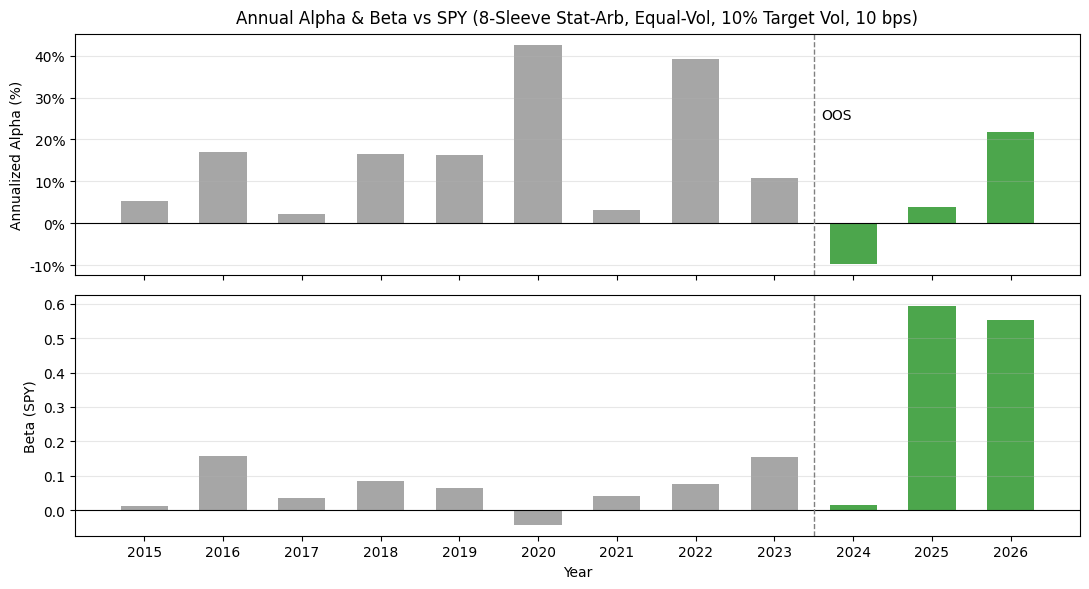

In [32]:
annual = [s for s in rows if len(s['period']) == 4]
years  = [int(s['period']) for s in annual]
alphas = [s['alpha_annual'] * 100 for s in annual]
betas  = [s['beta'] for s in annual]
p_vals = [s['p_alpha'] for s in annual]
colors = ['green' if s['label'] == 'OOS' else 'gray' for s in annual]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

bars = ax1.bar(years, alphas, color=colors, alpha=0.7, width=0.6)
        
ax1.axhline(0, color='black', lw=0.8)
ax1.axvline(2023.5, color='gray', ls='--', lw=1.0)
ax1.text(2023.6, 25, 'OOS')
ax1.set_ylabel('Annualized Alpha (%)')
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax1.set_title(
    'Annual Alpha & Beta vs SPY (8-Sleeve Stat-Arb, Equal-Vol, 10% Target Vol, 10 bps)',
    pad=8
)

ax1.grid(axis='y', alpha=0.3)

ax2.bar(years, betas, color=colors, alpha=0.7, width=0.6)
ax2.axhline(0, color='black', lw=0.8)
ax2.axvline(2023.5, color='gray', ls='--', lw=1.0, label='OOS')
ax2.set_ylabel('Beta (SPY)')
ax2.set_xlabel('Year')
ax2.set_xticks(years)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()